In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.5)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 3, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [4]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [5]:
intensity_matrix_quantum

Array([[[[0.+3.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-1.j, 0.+2.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-1.j, 0.+1.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-1.j, 0.-0.j, 0.-1.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-1.j, 0.-1.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-2.j, 0.-1.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-3.j]]]],      dtype=complex128)

In [6]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.33333333],
          [0.33333333],
          [0.33333333]]]], dtype=float64),
 Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.57735027],
          [0.57735027],
          [0.57735027]]]], dtype=float64))

In [7]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])

    for t in np.arange(1,20,0.1):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,20,0.1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [8]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d

,states,prior,time,real,imag
0,-3,Upper,0,0.010145635961905555,0.011821042090560745
1,-2,Upper,0,-0.01686481843129316,0.05589011501030169
2,-1,Upper,0,-0.15178692162863683,0.04406907291974094
3,0,Upper,0,-0.1955320256844788,-0.12971372576470497
4,1,Upper,0,-0.1519400950176157,0.02541397472765486
...,...,...,...,...,...
3985,-1,Lower,189,0.20755084464524684,0.022710684858011698
3986,0,Lower,189,0.278217537457275,-0.5404860315294402
3987,1,Lower,189,-0.3931677620667251,0.1502448515531028
3988,2,Lower,189,0.3198057289944398,0.09106419661343787


In [9]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [10]:
import plotly.express as px
pio.renderers.default = "vscode" #"browser"
fig = px.line_3d(df_quantum_3d.query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), x="Time", y="Real", z="Imaginary", color="states",
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Confidence States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=7
    ))
fig.update_layout(font=dict(
        
        size=15,  # Set the font size here
    ))
fig.show()

In [11]:
df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

,states,prior,time,real,imag


In [12]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [13]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

,0,1,2,3,4,5,6
0,0.001380,0.001378,0.001376,0.001375,0.001374,0.001373,0.001373
1,0.005514,0.005509,0.005503,0.005498,0.005495,0.005494,0.005494
2,0.016516,0.016508,0.016497,0.016489,0.016484,0.016483,0.016482
3,0.049489,0.049480,0.049467,0.049457,0.049452,0.049449,0.049449
4,0.148371,0.148366,0.148360,0.148355,0.148352,0.148351,0.148351
5,0.444997,0.445011,0.445031,0.445045,0.445053,0.445057,0.445057
6,0.333733,0.333747,0.333767,0.333781,0.333790,0.333793,0.333793


In [14]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

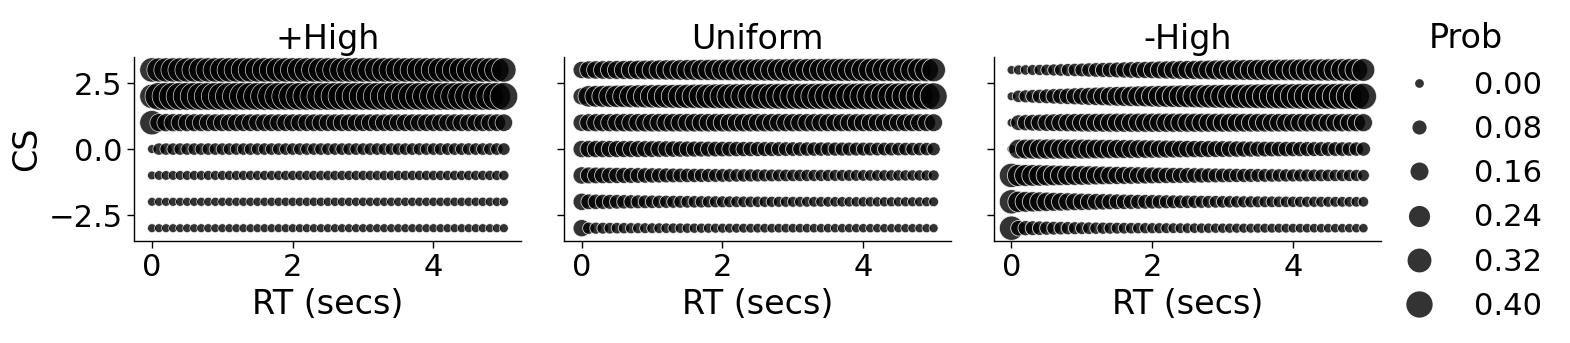

In [17]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_markov_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()


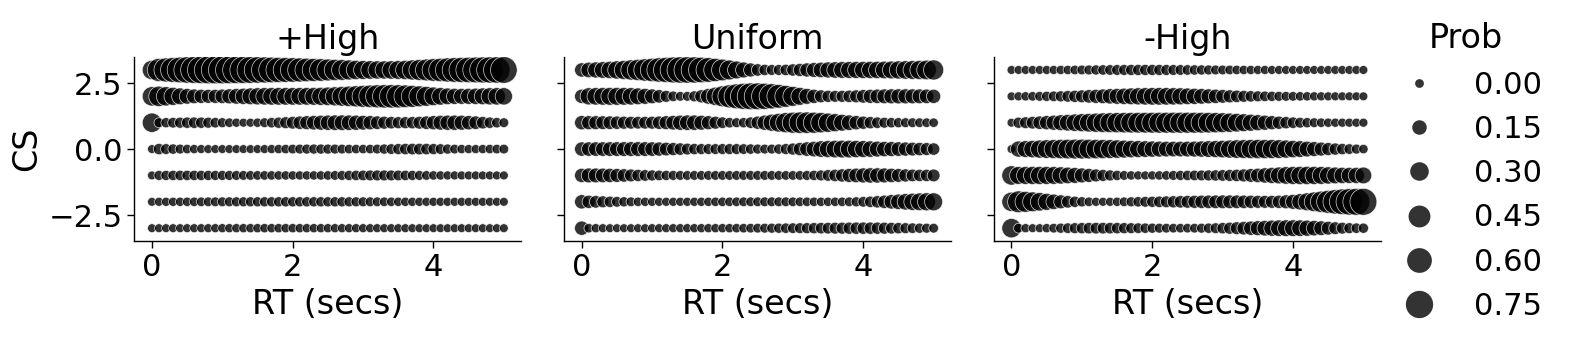

In [23]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [ ]:
fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

f = sns.relplot(df_quantum_plot.astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, height = 4.5)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [18]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [24]:
start_width

3

In [19]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.05]]), npx.asarray([[-0.05]]), npx.asarray([[1]]), npx.asarray([[-1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []

        #phi_markov_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)


        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        

[[[[-2.     0.975  0.     0.     0.     0.     0.   ]
   [ 2.    -2.     0.975  0.     0.     0.     0.   ]
   [ 0.     1.025 -2.     0.975  0.     0.     0.   ]
   [ 0.     0.     1.025 -2.     0.975  0.     0.   ]
   [ 0.     0.     0.     1.025 -2.     0.975  0.   ]
   [ 0.     0.     0.     0.     1.025 -2.     2.   ]
   [ 0.     0.     0.     0.     0.     1.025 -2.   ]]]]
[[[[-2.     1.025  0.     0.     0.     0.     0.   ]
   [ 2.    -2.     1.025  0.     0.     0.     0.   ]
   [ 0.     0.975 -2.     1.025  0.     0.     0.   ]
   [ 0.     0.     0.975 -2.     1.025  0.     0.   ]
   [ 0.     0.     0.     0.975 -2.     1.025  0.   ]
   [ 0.     0.     0.     0.     0.975 -2.     2.   ]
   [ 0.     0.     0.     0.     0.     0.975 -2.   ]]]]
[[[[-2.   0.5  0.   0.   0.   0.   0. ]
   [ 2.  -2.   0.5  0.   0.   0.   0. ]
   [ 0.   1.5 -2.   0.5  0.   0.   0. ]
   [ 0.   0.   1.5 -2.   0.5  0.   0. ]
   [ 0.   0.   0.   1.5 -2.   0.5  0. ]
   [ 0.   0.   0.   0.   1.5 -2.   2. 

In [20]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_markov1_plot.query("value > 3")

,prior,mu,time,value


In [ ]:
df_markov1_plot

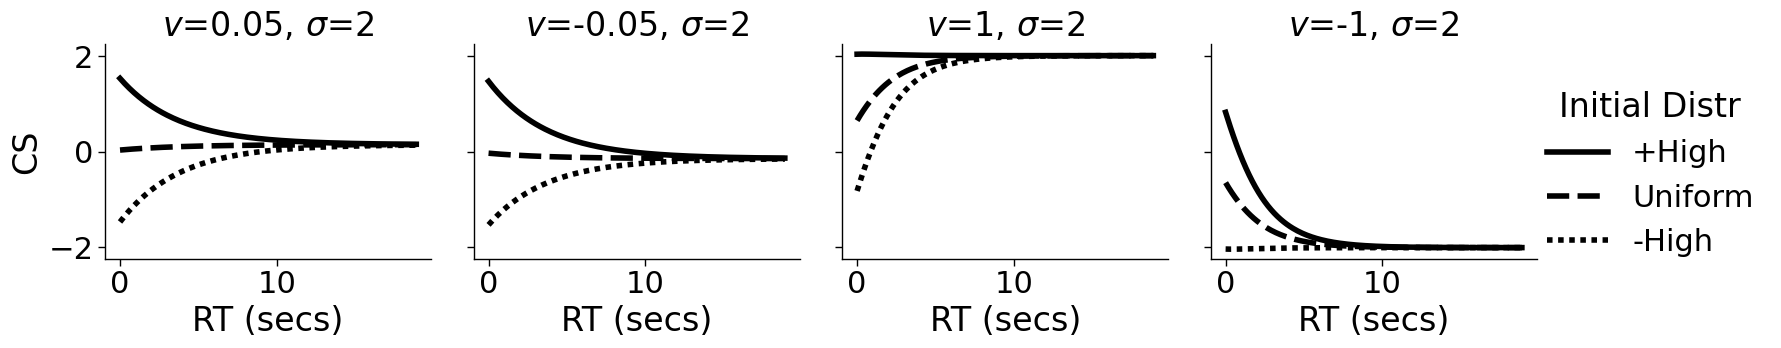

In [21]:
f = sns.relplot(df_markov1_plot, x="time", y="value", 
                style="prior", col="mu", color="black", aspect=1, height=4, kind="line",lw=4)
f.legend.set_title("Initial Distr")
f.set_titles("{col_name}")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")


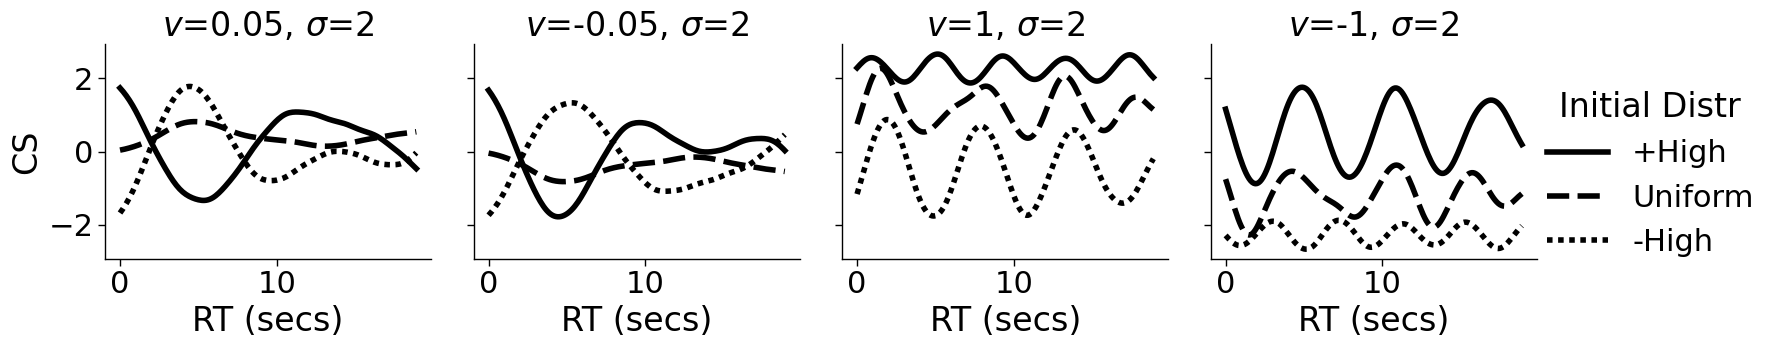

In [22]:
f = sns.relplot(df_quantum1_plot, x="time", y="value", 
                style="prior", col="mu", color="black", aspect=1, height=4, kind="line",lw=4)
f.legend.set_title("Initial Distr")
f.set_titles("{col_name}")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")

In [ ]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i